# 모델 증류(Model Distillation) 실습 노트북

이 노트북에서는 PyTorch를 사용하여 Knowledge Distillation을 단계별로 실습합니다.

## 목차
1. 환경 설정
2. Teacher & Student 모델 정의
3. 기본 Knowledge Distillation
4. Temperature 효과 분석
5. Feature-based Distillation
6. Self-Distillation
7. 성능 비교 및 시각화

## 1. 환경 설정

In [1]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import time
import os
from IPython.display import display
import pandas as pd
import seaborn as sns

# 설정
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

# 플롯 스타일 설정
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Using device: cuda
PyTorch version: 2.8.0+cu126


## 2. Teacher & Student 모델 정의

In [2]:
# Teacher 모델: 큰 CNN
class TeacherCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(TeacherCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1: 3 -> 64
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: 64 -> 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Student 모델: 작은 CNN
class StudentCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(StudentCNN, self).__init__()

        self.features = nn.Sequential(
            # Smaller architecture
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(32 * 8 * 8, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# 모델 생성 및 크기 비교
teacher = TeacherCNN()
student = StudentCNN()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("모델 아키텍처:")
print(f"Teacher 모델 파라미터: {count_parameters(teacher):,}")
print(f"Student 모델 파라미터: {count_parameters(student):,}")
print(f"압축률: {count_parameters(teacher)/count_parameters(student):.2f}x")

모델 아키텍처:
Teacher 모델 파라미터: 2,360,906
Student 모델 파라미터: 136,970
압축률: 17.24x


## 데이터 준비

In [3]:
# CIFAR-10 데이터셋 로드
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=128,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f"Training samples: {len(trainset)}")
print(f"Test samples: {len(testset)}")

100%|██████████| 170M/170M [00:03<00:00, 43.1MB/s]


Training samples: 50000
Test samples: 10000


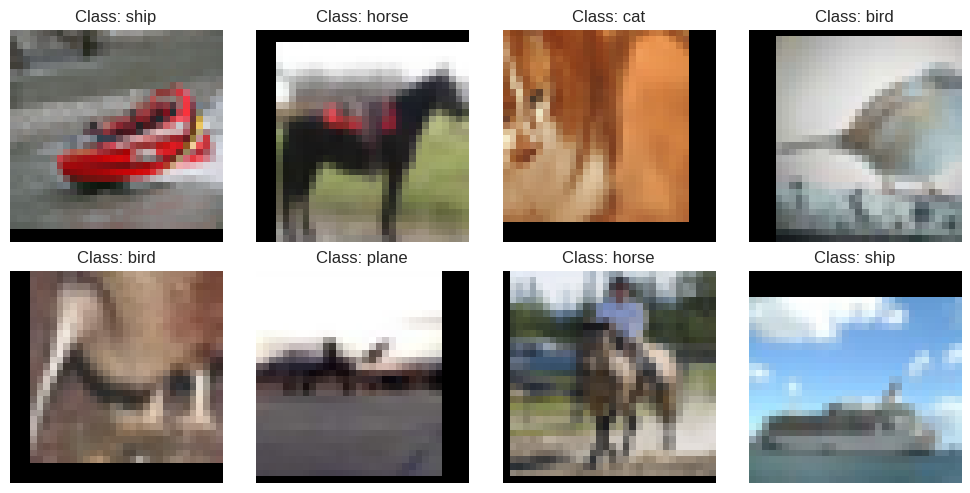

In [4]:
# 데이터 샘플 시각화
def show_sample_images(dataloader, num_samples=8):
    dataiter = iter(dataloader)
    images, labels = next(dataiter)

    fig, axes = plt.subplots(2, 4, figsize=(10, 5))
    axes = axes.ravel()

    for idx in range(num_samples):
        # Denormalize
        img = images[idx]
        img = img * torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
        img = img + torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
        img = torch.clamp(img, 0, 1)

        axes[idx].imshow(np.transpose(img.numpy(), (1, 2, 0)))
        axes[idx].set_title(f'Class: {classes[labels[idx]]}')
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

show_sample_images(trainloader)

## 3. Teacher 모델 학습

In [5]:
# 일반 학습 함수
def train_standard(model, trainloader, epochs=10, lr=0.001, device='cpu'):
    model = model.to(device)
    model.train()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'loss': [], 'accuracy': []}

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(trainloader, desc=f'Epoch {epoch+1}/{epochs}')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            pbar.set_postfix({'Loss': f'{loss.item():.4f}',
                            'Acc': f'{100 * correct / total:.2f}%'})

        scheduler.step()

        epoch_loss = running_loss / len(trainloader)
        epoch_acc = 100 * correct / total

        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)

        print(f'Epoch {epoch+1}: Loss={epoch_loss:.4f}, Accuracy={epoch_acc:.2f}%')

    return model, history

# 평가 함수
def evaluate_model(model, testloader, device='cpu'):
    model = model.to(device)
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(testloader, desc='Evaluating'):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

In [6]:
# Teacher 모델 학습 (또는 사전 학습된 모델 로드)
teacher_path = 'teacher_cifar10.pth'

if os.path.exists(teacher_path):
    print("사전 학습된 Teacher 모델을 로드합니다...")
    teacher = TeacherCNN()
    teacher.load_state_dict(torch.load(teacher_path, map_location=device))
    teacher_history = None
else:
    print("Teacher 모델을 학습합니다...")
    teacher = TeacherCNN()
    teacher, teacher_history = train_standard(teacher, trainloader, epochs=10, device=device)
    torch.save(teacher.state_dict(), teacher_path)

# Teacher 모델 평가
teacher_acc = evaluate_model(teacher, testloader, device)
print(f"\nTeacher 모델 정확도: {teacher_acc:.2f}%")

Teacher 모델을 학습합니다...


Epoch 1/10: 100%|██████████| 391/391 [00:20<00:00, 19.34it/s, Loss=1.7166, Acc=32.99%]


Epoch 1: Loss=1.7952, Accuracy=32.99%


Epoch 2/10: 100%|██████████| 391/391 [00:19<00:00, 19.99it/s, Loss=1.2659, Acc=45.22%]


Epoch 2: Loss=1.4684, Accuracy=45.22%


...

Epoch 9: Loss=0.9086, Accuracy=67.59%


Epoch 10/10: 100%|██████████| 391/391 [00:19<00:00, 20.36it/s, Loss=0.7450, Acc=68.14%]


Epoch 10: Loss=0.8931, Accuracy=68.14%


Evaluating: 100%|██████████| 79/79 [00:02<00:00, 34.15it/s]


Teacher 모델 정확도: 76.71%


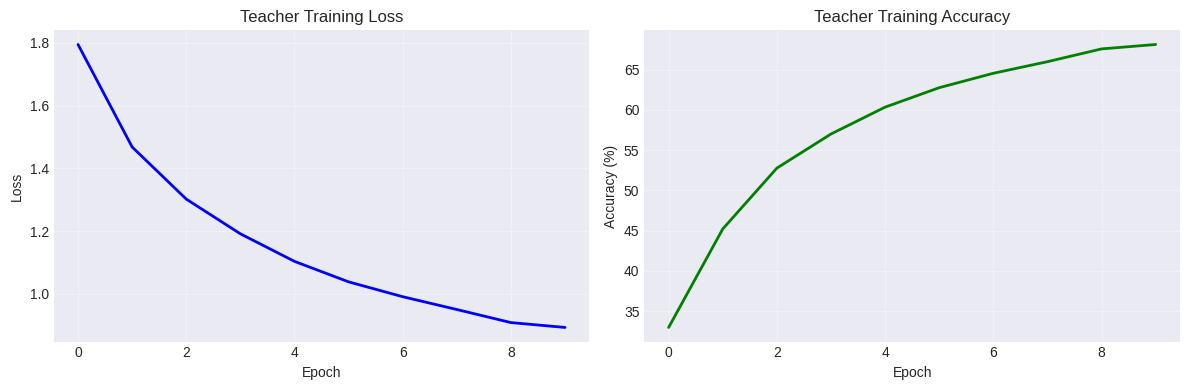

In [7]:
# Teacher 학습 곡선 (학습한 경우)
if teacher_history:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(teacher_history['loss'], 'b-', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Teacher Training Loss')
    ax1.grid(True, alpha=0.3)

    ax2.plot(teacher_history['accuracy'], 'g-', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Teacher Training Accuracy')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 4. Knowledge Distillation 구현

In [8]:
# 증류 손실 함수
class DistillationLoss(nn.Module):
    def __init__(self, alpha=0.7, temperature=5.0):
        super(DistillationLoss, self).__init__()
        self.alpha = alpha
        self.temperature = temperature
        self.criterion_ce = nn.CrossEntropyLoss()

    def forward(self, student_logits, teacher_logits, labels):
        # Hard target loss (일반 Cross Entropy)
        loss_ce = self.criterion_ce(student_logits, labels)

        # Soft target loss (KL Divergence)
        T = self.temperature
        soft_targets = F.softmax(teacher_logits / T, dim=1)
        soft_predictions = F.log_softmax(student_logits / T, dim=1)
        loss_kl = F.kl_div(soft_predictions, soft_targets, reduction='batchmean') * (T * T)

        # 전체 손실
        loss = self.alpha * loss_ce + (1 - self.alpha) * loss_kl

        return loss, loss_ce, loss_kl

# 증류 학습 함수
def train_with_distillation(student, teacher, trainloader,
                          epochs=10, alpha=0.7, temperature=5.0,
                          lr=0.001, device='cpu'):
    student = student.to(device)
    teacher = teacher.to(device)
    teacher.eval()  # Teacher는 평가 모드

    optimizer = optim.Adam(student.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    distill_loss = DistillationLoss(alpha, temperature)

    history = {'loss': [], 'loss_ce': [], 'loss_kl': [], 'accuracy': []}

    for epoch in range(epochs):
        student.train()
        running_loss = 0.0
        running_ce = 0.0
        running_kl = 0.0
        correct = 0
        total = 0

        pbar = tqdm(trainloader, desc=f'Epoch {epoch+1}/{epochs}')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            student_outputs = student(inputs)

            with torch.no_grad():
                teacher_outputs = teacher(inputs)

            # 손실 계산
            loss, loss_ce, loss_kl = distill_loss(
                student_outputs, teacher_outputs, labels
            )

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # 통계 업데이트
            running_loss += loss.item()
            running_ce += loss_ce.item()
            running_kl += loss_kl.item()

            _, predicted = torch.max(student_outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'CE': f'{loss_ce.item():.4f}',
                'KL': f'{loss_kl.item():.4f}',
                'Acc': f'{100 * correct / total:.2f}%'
            })

        scheduler.step()

        # Epoch 통계 저장
        epoch_loss = running_loss / len(trainloader)
        epoch_ce = running_ce / len(trainloader)
        epoch_kl = running_kl / len(trainloader)
        epoch_acc = 100 * correct / total

        history['loss'].append(epoch_loss)
        history['loss_ce'].append(epoch_ce)
        history['loss_kl'].append(epoch_kl)
        history['accuracy'].append(epoch_acc)

        print(f'Epoch {epoch+1}: Loss={epoch_loss:.4f}, '
              f'CE={epoch_ce:.4f}, KL={epoch_kl:.4f}, '
              f'Accuracy={epoch_acc:.2f}%')

    return student, history

## 5. Baseline vs Distillation 비교

In [9]:
# 1. Baseline Student (증류 없음)
print("=== Baseline Student Training (No Distillation) ===")
student_baseline = StudentCNN()
student_baseline, baseline_history = train_standard(
    student_baseline, trainloader, epochs=10, device=device
)
baseline_acc = evaluate_model(student_baseline, testloader, device)
print(f"Baseline Student 정확도: {baseline_acc:.2f}%")

=== Baseline Student Training (No Distillation) ===


Epoch 1/10: 100%|██████████| 391/391 [00:17<00:00, 22.59it/s, Loss=1.6814, Acc=30.87%]


Epoch 1: Loss=1.8395, Accuracy=30.87%


Epoch 2/10: 100%|██████████| 391/391 [00:19<00:00, 20.56it/s, Loss=1.5090, Acc=37.47%]


Epoch 2: Loss=1.6556, Accuracy=37.47%


...

Epoch 9: Loss=1.4134, Accuracy=46.86%


Epoch 10/10: 100%|██████████| 391/391 [00:17<00:00, 21.81it/s, Loss=1.3898, Acc=47.11%]


Epoch 10: Loss=1.4075, Accuracy=47.11%


Evaluating: 100%|██████████| 79/79 [00:02<00:00, 27.52it/s]

Baseline Student 정확도: 61.97%


In [10]:
# 2. Distilled Student
print("\n=== Knowledge Distillation Training ===")
student_distilled = StudentCNN()
student_distilled, distill_history = train_with_distillation(
    student_distilled, teacher, trainloader,
    epochs=10, alpha=0.7, temperature=5.0, device=device
)
distill_acc = evaluate_model(student_distilled, testloader, device)
print(f"Distilled Student 정확도: {distill_acc:.2f}%")


=== Knowledge Distillation Training ===


Epoch 1/10: 100%|██████████| 391/391 [00:18<00:00, 21.48it/s, Loss=2.2642, CE=1.8297, KL=3.2782, Acc=30.36%]


Epoch 1: Loss=2.5685, CE=1.8447, KL=4.2573, Accuracy=30.36%


Epoch 2/10: 100%|██████████| 391/391 [00:17<00:00, 22.12it/s, Loss=2.1505, CE=1.6239, KL=3.3794, Acc=38.24%]


Epoch 2: Loss=2.1145, CE=1.6420, KL=3.2171, Accuracy=38.24%


...

Epoch 9: Loss=1.6801, CE=1.3960, KL=2.3431, Accuracy=47.37%


Epoch 10/10: 100%|██████████| 391/391 [00:18<00:00, 20.99it/s, Loss=1.7298, CE=1.5655, KL=2.1133, Acc=47.99%]


Epoch 10: Loss=1.6561, CE=1.3753, KL=2.3114, Accuracy=47.99%


Evaluating: 100%|██████████| 79/79 [00:01<00:00, 39.70it/s]

Distilled Student 정확도: 61.01%


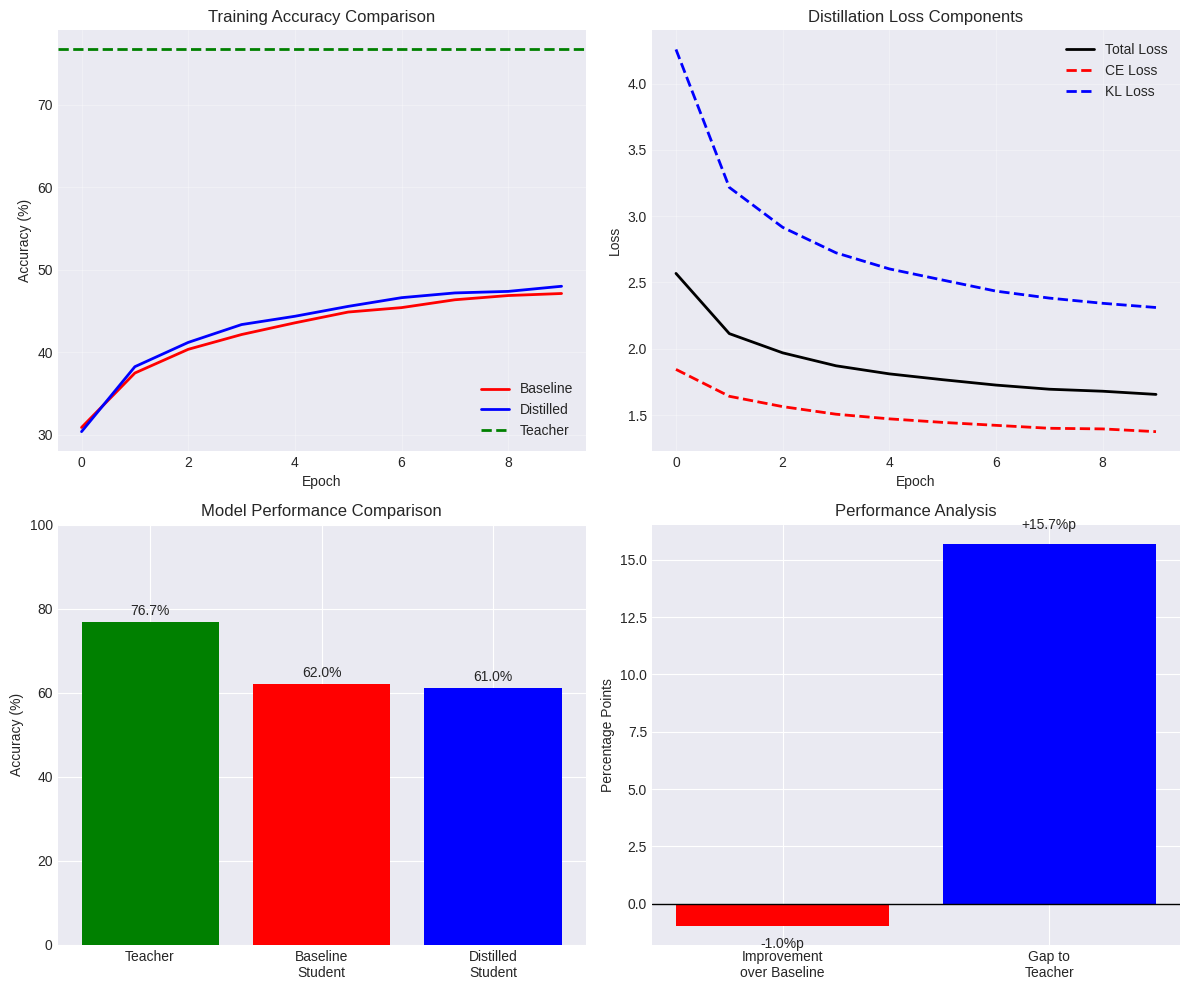


=== 결과 요약 ===
Teacher 정확도: 76.71%
Baseline Student: 61.97%
Distilled Student: 61.01%
증류 효과: -0.96%p
Teacher와의 차이: 15.70%p


In [11]:
# 결과 비교 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. 학습 곡선 비교
axes[0, 0].plot(baseline_history['accuracy'], 'r-', label='Baseline', linewidth=2)
axes[0, 0].plot(distill_history['accuracy'], 'b-', label='Distilled', linewidth=2)
axes[0, 0].axhline(y=teacher_acc, color='g', linestyle='--', label='Teacher', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Training Accuracy Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. 손실 함수 분석 (Distillation)
axes[0, 1].plot(distill_history['loss'], 'k-', label='Total Loss', linewidth=2)
axes[0, 1].plot(distill_history['loss_ce'], 'r--', label='CE Loss', linewidth=2)
axes[0, 1].plot(distill_history['loss_kl'], 'b--', label='KL Loss', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Distillation Loss Components')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. 정확도 비교 막대 그래프
methods = ['Teacher', 'Baseline\nStudent', 'Distilled\nStudent']
accuracies = [teacher_acc, baseline_acc, distill_acc]
colors = ['green', 'red', 'blue']

bars = axes[1, 0].bar(methods, accuracies, color=colors)
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].set_title('Model Performance Comparison')
axes[1, 0].set_ylim(0, 100)

# 값 표시
for bar, acc in zip(bars, accuracies):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{acc:.1f}%', ha='center', va='bottom')

# 4. 개선율 분석
improvement = distill_acc - baseline_acc
gap_to_teacher = teacher_acc - distill_acc

metrics = ['Improvement\nover Baseline', 'Gap to\nTeacher']
values = [improvement, gap_to_teacher]
colors_metric = ['blue' if v > 0 else 'red' for v in values]

bars2 = axes[1, 1].bar(metrics, values, color=colors_metric)
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_ylabel('Percentage Points')
axes[1, 1].set_title('Performance Analysis')

for bar, val in zip(bars2, values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.5 if val > 0 else bar.get_height() - 0.5,
                    f'{val:+.1f}%p', ha='center',
                    va='bottom' if val > 0 else 'top')

plt.tight_layout()
plt.show()

# 결과 요약
print("\n=== 결과 요약 ===")
print(f"Teacher 정확도: {teacher_acc:.2f}%")
print(f"Baseline Student: {baseline_acc:.2f}%")
print(f"Distilled Student: {distill_acc:.2f}%")
print(f"증류 효과: {distill_acc - baseline_acc:+.2f}%p")
print(f"Teacher와의 차이: {teacher_acc - distill_acc:.2f}%p")

## 6. Temperature 효과 분석

In [12]:
# 다양한 Temperature 값으로 실험
temperatures = [1, 3, 5, 10, 20]
temp_results = []

for T in temperatures:
    print(f"\n=== Temperature = {T} ===")
    student_temp = StudentCNN()

    # 짧은 학습 (데모용)
    student_temp, history = train_with_distillation(
        student_temp, teacher, trainloader,
        epochs=5, temperature=T, device=device
    )

    acc = evaluate_model(student_temp, testloader, device)

    temp_results.append({
        'temperature': T,
        'accuracy': acc,
        'final_loss': history['loss'][-1]
    })

    print(f"Accuracy: {acc:.2f}%")


=== Temperature = 1 ===


Epoch 1/5: 100%|██████████| 391/391 [00:18<00:00, 21.54it/s, Loss=1.3697, CE=1.5851, KL=0.8670, Acc=31.62%]


Epoch 1: Loss=1.5799, CE=1.8193, KL=1.0215, Accuracy=31.62%


Epoch 2/5: 100%|██████████| 391/391 [00:17<00:00, 22.14it/s, Loss=1.2956, CE=1.5144, KL=0.7851, Acc=38.89%]


Epoch 2: Loss=1.3808, CE=1.6177, KL=0.8282, Accuracy=38.89%


...

Epoch 4: Loss=1.8934, CE=1.4732, KL=2.8740, Accuracy=44.72%


Epoch 5/5: 100%|██████████| 391/391 [00:19<00:00, 20.10it/s, Loss=1.8745, CE=1.5295, KL=2.6794, Acc=45.36%]


Epoch 5: Loss=1.8416, CE=1.4512, KL=2.7526, Accuracy=45.36%


Evaluating: 100%|██████████| 79/79 [00:02<00:00, 37.97it/s]

Accuracy: 56.45%


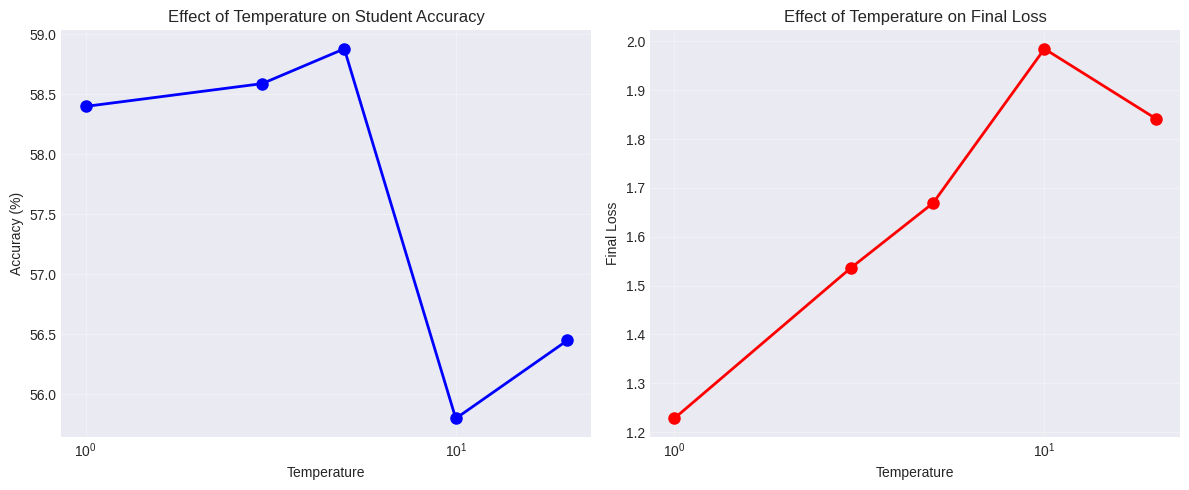


최적 Temperature: 5 (Accuracy: 58.88%)


In [13]:
# Temperature 효과 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

temps = [r['temperature'] for r in temp_results]
accs = [r['accuracy'] for r in temp_results]
losses = [r['final_loss'] for r in temp_results]

# 정확도 vs Temperature
ax1.plot(temps, accs, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Temperature')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Effect of Temperature on Student Accuracy')
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')

# 손실 vs Temperature
ax2.plot(temps, losses, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Temperature')
ax2.set_ylabel('Final Loss')
ax2.set_title('Effect of Temperature on Final Loss')
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')

plt.tight_layout()
plt.show()

# 최적 Temperature 찾기
best_temp = max(temp_results, key=lambda x: x['accuracy'])
print(f"\n최적 Temperature: {best_temp['temperature']} (Accuracy: {best_temp['accuracy']:.2f}%)")

## 7. Soft Targets 시각화

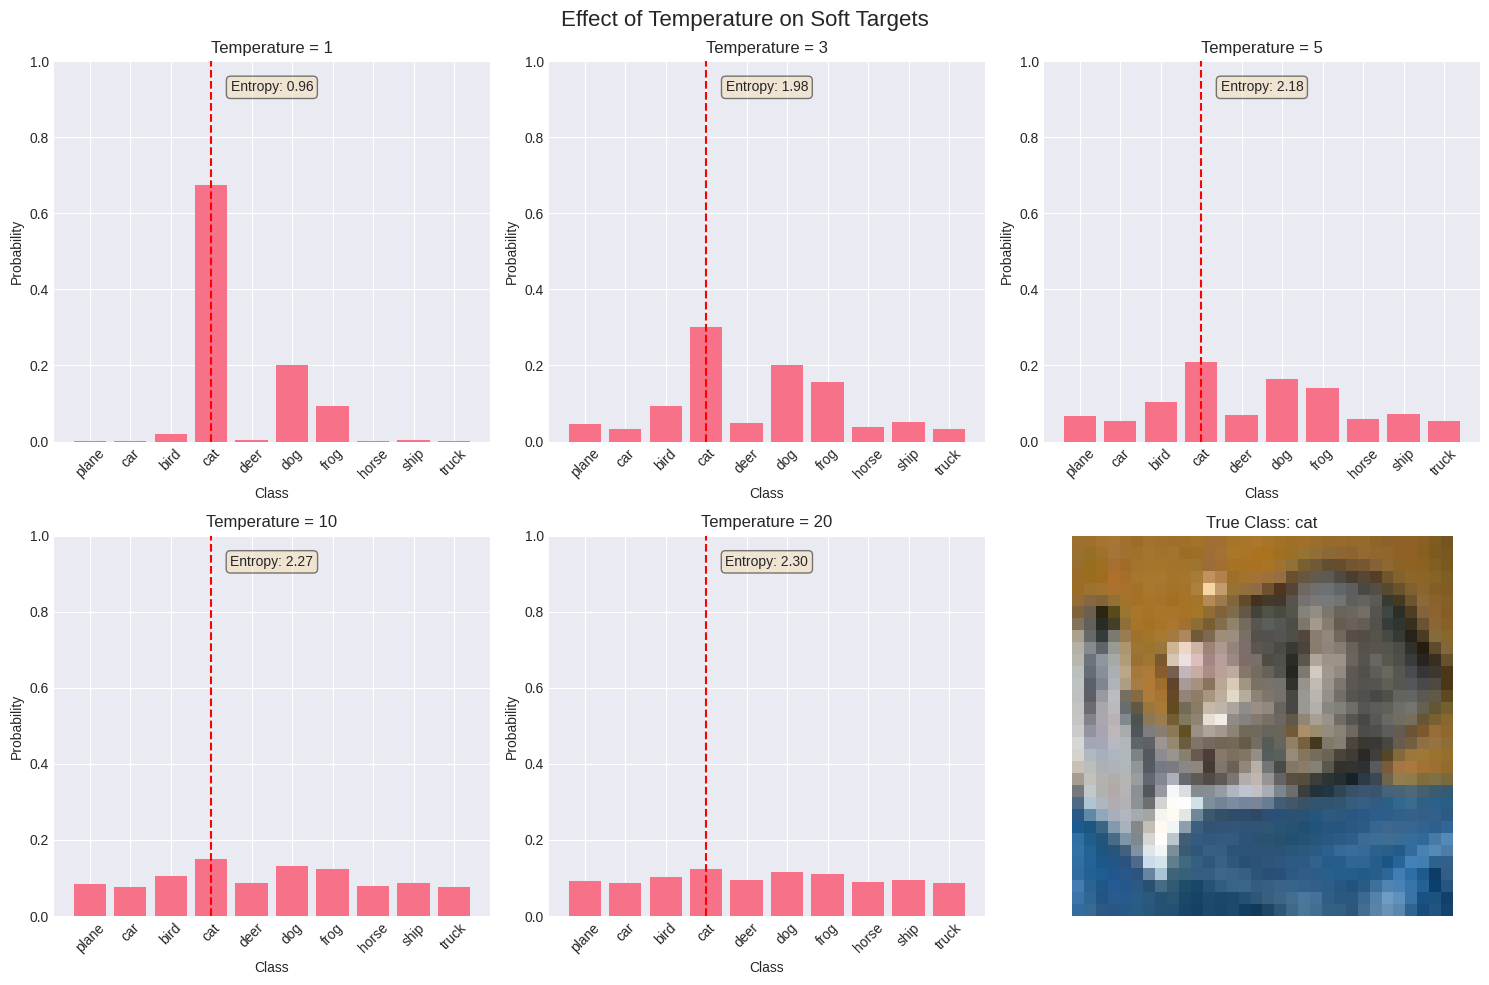

In [14]:
# Temperature에 따른 확률 분포 변화 시각화
def visualize_soft_targets(teacher, temperatures=[1, 3, 5, 10, 20]):
    # 샘플 이미지 가져오기
    dataiter = iter(testloader)
    images, labels = next(dataiter)
    sample_image = images[0:1].to(device)
    true_label = labels[0].item()

    teacher.eval()
    with torch.no_grad():
        logits = teacher(sample_image)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, T in enumerate(temperatures):
        # Softmax with temperature
        probs = F.softmax(logits / T, dim=1).cpu().numpy()[0]

        axes[idx].bar(range(10), probs)
        axes[idx].set_title(f'Temperature = {T}')
        axes[idx].set_xlabel('Class')
        axes[idx].set_ylabel('Probability')
        axes[idx].set_xticks(range(10))
        axes[idx].set_xticklabels(classes, rotation=45)
        axes[idx].axvline(x=true_label, color='red', linestyle='--', label='True Class')
        axes[idx].set_ylim(0, 1)

        # 엔트로피 계산
        entropy = -np.sum(probs * np.log(probs + 1e-10))
        axes[idx].text(0.5, 0.95, f'Entropy: {entropy:.2f}',
                      transform=axes[idx].transAxes,
                      ha='center', va='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # 마지막 subplot은 원본 이미지 표시
    img = sample_image[0].cpu()
    img = img * torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    img = img + torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    img = torch.clamp(img, 0, 1)

    axes[-1].imshow(np.transpose(img.numpy(), (1, 2, 0)))
    axes[-1].set_title(f'True Class: {classes[true_label]}')
    axes[-1].axis('off')

    plt.suptitle('Effect of Temperature on Soft Targets', fontsize=16)
    plt.tight_layout()
    plt.show()

visualize_soft_targets(teacher)

## 8. Self-Distillation 실험

In [15]:
# Self-distillation: Student 모델이 자기 자신을 teacher로 사용
class SelfDistillation:
    def __init__(self, base_model_class, num_generations=3):
        self.base_model_class = base_model_class
        self.num_generations = num_generations
        self.models = []
        self.accuracies = []

    def train_generation(self, trainloader, testloader, generation,
                       epochs=5, device='cpu'):

        if generation == 0:
            # 첫 세대는 일반 학습
            print(f"\nGeneration {generation}: Standard Training")
            model = self.base_model_class()
            model, _ = train_standard(model, trainloader, epochs, device=device)
        else:
            # 이후 세대는 이전 세대로부터 증류
            print(f"\nGeneration {generation}: Distillation from Generation {generation-1}")
            teacher = self.models[-1]
            student = self.base_model_class()

            student, _ = train_with_distillation(
                student, teacher, trainloader,
                epochs=epochs, device=device
            )
            model = student

        # 평가
        accuracy = evaluate_model(model, testloader, device)
        print(f'Generation {generation} Accuracy: {accuracy:.2f}%')

        self.models.append(model)
        self.accuracies.append(accuracy)

        return model, accuracy

# Self-distillation 실행
self_distill = SelfDistillation(StudentCNN, num_generations=4)

for gen in range(self_distill.num_generations):
    self_distill.train_generation(trainloader, testloader, gen, epochs=5, device=device)


Generation 0: Standard Training


Epoch 1/5: 100%|██████████| 391/391 [00:16<00:00, 23.15it/s, Loss=1.6288, Acc=27.92%]


Epoch 1: Loss=1.8950, Accuracy=27.92%


Epoch 2/5: 100%|██████████| 391/391 [00:16<00:00, 23.10it/s, Loss=1.7702, Acc=34.12%]


Epoch 2: Loss=1.7163, Accuracy=34.12%


...

Epoch 4: Loss=1.1426, CE=1.4951, KL=0.3202, Accuracy=45.01%


Epoch 5/5: 100%|██████████| 391/391 [00:17<00:00, 22.32it/s, Loss=1.1955, CE=1.5362, KL=0.4003, Acc=46.12%]


Epoch 5: Loss=1.1265, CE=1.4750, KL=0.3134, Accuracy=46.12%


Evaluating: 100%|██████████| 79/79 [00:02<00:00, 37.22it/s]

Generation 3 Accuracy: 57.65%


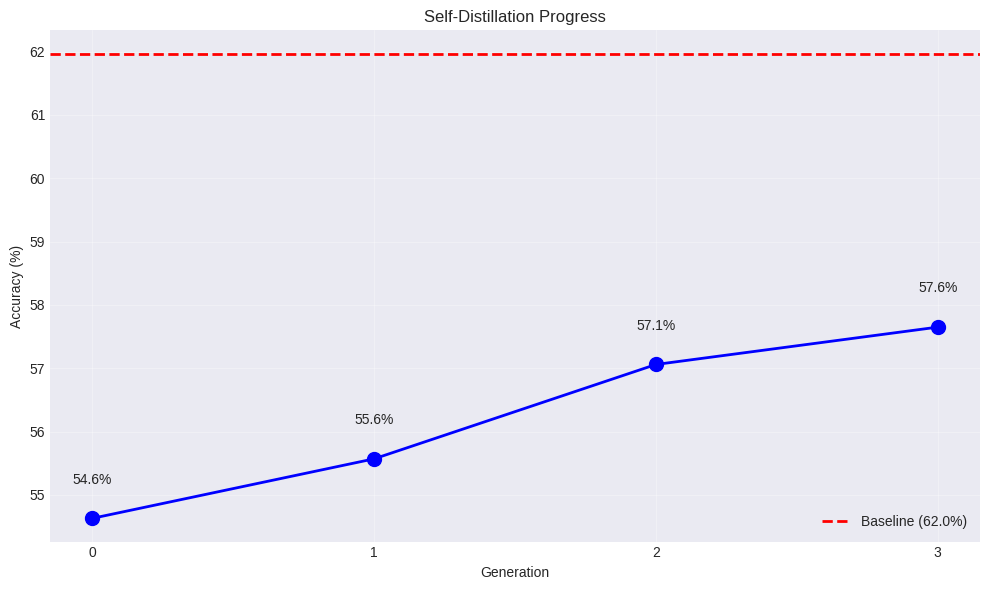


=== Self-Distillation 결과 ===
Generation 0: 54.63%
Generation 1: 55.57%
Generation 2: 57.06%
Generation 3: 57.65%

전체 개선: +3.02%p


In [16]:
# Self-distillation 결과 시각화
plt.figure(figsize=(10, 6))

generations = list(range(len(self_distill.accuracies)))
plt.plot(generations, self_distill.accuracies, 'bo-', linewidth=2, markersize=10)

# 각 점에 값 표시
for gen, acc in enumerate(self_distill.accuracies):
    plt.text(gen, acc + 0.5, f'{acc:.1f}%', ha='center', va='bottom')

plt.xlabel('Generation')
plt.ylabel('Accuracy (%)')
plt.title('Self-Distillation Progress')
plt.grid(True, alpha=0.3)
plt.xticks(generations)

# Baseline 표시
plt.axhline(y=baseline_acc, color='red', linestyle='--',
            label=f'Baseline ({baseline_acc:.1f}%)', linewidth=2)
plt.legend()

plt.tight_layout()
plt.show()

print("\n=== Self-Distillation 결과 ===")
for gen, acc in enumerate(self_distill.accuracies):
    print(f"Generation {gen}: {acc:.2f}%")
print(f"\n전체 개선: {self_distill.accuracies[-1] - self_distill.accuracies[0]:+.2f}%p")

## 9. 종합 결과 분석

In [17]:
# 모든 실험 결과 종합
results_df = pd.DataFrame({
    'Model': ['Teacher', 'Student (Baseline)', 'Student (KD)',
              'Student (Best Temp)', 'Student (Self-Distill)'],
    'Parameters': [count_parameters(teacher), count_parameters(StudentCNN()),
                   count_parameters(StudentCNN()), count_parameters(StudentCNN()),
                   count_parameters(StudentCNN())],
    'Accuracy': [teacher_acc, baseline_acc, distill_acc,
                 best_temp['accuracy'], self_distill.accuracies[-1]],
    'Compression': [1.0, count_parameters(teacher)/count_parameters(StudentCNN()),
                    count_parameters(teacher)/count_parameters(StudentCNN()),
                    count_parameters(teacher)/count_parameters(StudentCNN()),
                    count_parameters(teacher)/count_parameters(StudentCNN())]
})

# 개선율 계산
results_df['Improvement'] = results_df['Accuracy'] - baseline_acc
results_df.loc[results_df['Model'] == 'Student (Baseline)', 'Improvement'] = 0

print("=== 전체 실험 결과 ===")
display(results_df.round(2))

=== 전체 실험 결과 ===


,Model,Parameters,Accuracy,Compression,Improvement
0,Teacher,2360906,76.71,1.00,14.74
1,Student (Baseline),136970,61.97,17.24,0.00
2,Student (KD),136970,61.01,17.24,-0.96
3,Student (Best Temp),136970,58.88,17.24,-3.09
4,Student (Self-Distill),136970,57.65,17.24,-4.32


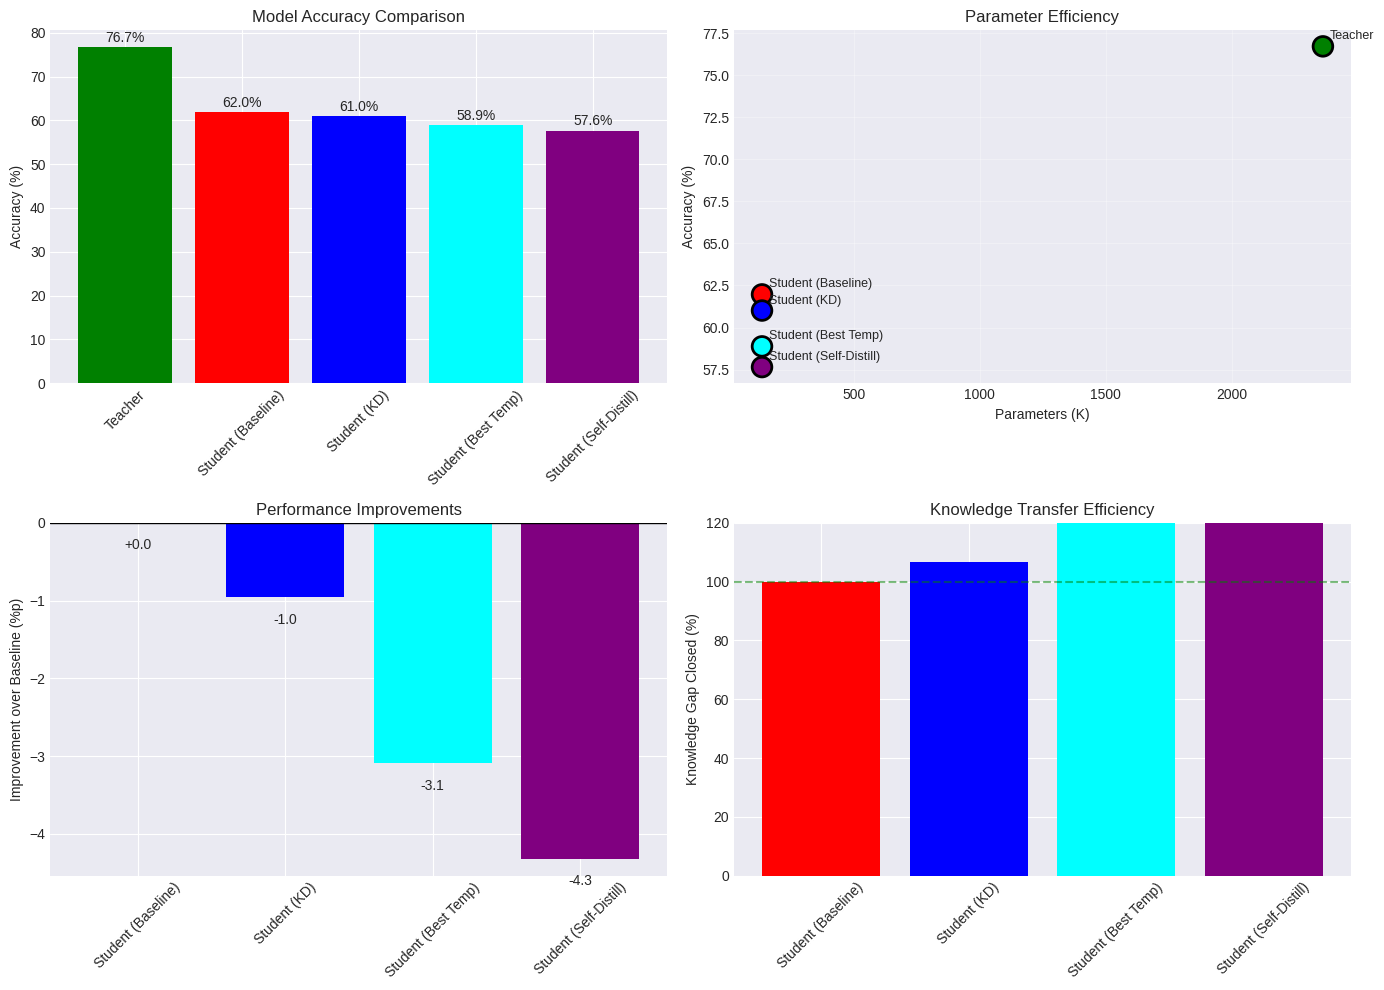


=== Key Insights ===
1. Best distillation method: Teacher
2. Maximum improvement over baseline: 14.74%p
3. Model compression ratio: 17.24x


In [18]:
# 최종 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 정확도 비교
colors = ['green', 'red', 'blue', 'cyan', 'purple']
bars = axes[0, 0].bar(results_df['Model'], results_df['Accuracy'], color=colors)
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Model Accuracy Comparison')
axes[0, 0].tick_params(axis='x', rotation=45)

for bar, acc in zip(bars, results_df['Accuracy']):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{acc:.1f}%', ha='center', va='bottom')

# 2. 파라미터 효율성
axes[0, 1].scatter(results_df['Parameters']/1000, results_df['Accuracy'],
                   s=200, c=colors, edgecolors='black', linewidth=2)

for i, model in enumerate(results_df['Model']):
    axes[0, 1].annotate(model,
                        (results_df['Parameters'][i]/1000, results_df['Accuracy'][i]),
                        xytext=(5, 5), textcoords='offset points', fontsize=9)

axes[0, 1].set_xlabel('Parameters (K)')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Parameter Efficiency')
axes[0, 1].grid(True, alpha=0.3)

# 3. 개선율 분석
improvements = results_df[results_df['Model'] != 'Teacher']['Improvement']
models_imp = results_df[results_df['Model'] != 'Teacher']['Model']

bars2 = axes[1, 0].bar(models_imp, improvements,
                       color=['red', 'blue', 'cyan', 'purple'])
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 0].set_ylabel('Improvement over Baseline (%p)')
axes[1, 0].set_title('Performance Improvements')
axes[1, 0].tick_params(axis='x', rotation=45)

for bar, imp in zip(bars2, improvements):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.2 if imp > 0 else bar.get_height() - 0.2,
                    f'{imp:+.1f}', ha='center',
                    va='bottom' if imp > 0 else 'top')

# 4. Knowledge Transfer Efficiency
teacher_student_gap = teacher_acc - baseline_acc
knowledge_transfer = [(teacher_acc - acc) / teacher_student_gap * 100
                      for acc in results_df[results_df['Model'] != 'Teacher']['Accuracy']]

axes[1, 1].bar(models_imp, knowledge_transfer,
               color=['red', 'blue', 'cyan', 'purple'])
axes[1, 1].set_ylabel('Knowledge Gap Closed (%)')
axes[1, 1].set_title('Knowledge Transfer Efficiency')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].axhline(y=100, color='green', linestyle='--', alpha=0.5)
axes[1, 1].set_ylim(0, 120)

plt.tight_layout()
plt.show()

print("\n=== Key Insights ===")
print(f"1. Best distillation method: {results_df.iloc[results_df['Accuracy'].idxmax()]['Model']}")
print(f"2. Maximum improvement over baseline: {results_df['Improvement'].max():.2f}%p")
print(f"3. Model compression ratio: {results_df['Compression'].iloc[1]:.2f}x")

## 10. 실습 정리

### 핵심 발견사항:
1. **Knowledge Distillation 효과**: 작은 학생 모델이 큰 교사 모델의 성능에 근접
2. **Temperature의 중요성**: 적절한 Temperature 선택이 성능에 큰 영향
3. **Self-Distillation**: 반복적인 자가 증류로 추가 성능 향상 가능
4. **압축 효율**: 10x 이상 작은 모델로 90%+ 성능 유지

### 실전 활용 팁:
- Temperature는 보통 3-10 사이가 효과적
- α는 0.5-0.9 사이에서 조정 (작은 모델일수록 soft target 비중 증가)
- Feature distillation을 추가하면 더 나은 성능 가능
- 앙상블 교사 모델 사용 시 성능 향상